# Retail Sales Forecasting using Machine Learning

## Objective

Develop machine learning models to predict retail sales based on historical transaction data.

The notebook includes:

- Data Preparation
- Feature Engineering
- Model Training
- Model Evaluation
- Business Interpretation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("data/processed/superstore_cleaned.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Day,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,2016,11,November,4,8,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2016,11,November,4,8,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,2016,6,June,2,12,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,10,October,4,11,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,2015,10,October,4,11,7


In [3]:
print("Shape:", df.shape)

df.info()

Shape: (9994, 27)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   str           
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category  

## Feature Selection

The following numerical features are used for sales prediction.

In [4]:
features = [
    "Quantity",
    "Discount",
    "Shipping Days",
    "Year",
    "Month",
    "Quarter"
]

target = "Sales"

X = df[features]

y = df[target]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (7995, 6)
Testing Data: (1999, 6)


# Model 1 — Linear Regression

In [6]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

In [7]:
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(lr_mae,2))
print("RMSE:", round(lr_rmse,2))
print("R² :", round(lr_r2,3))

Linear Regression Results
-------------------------
MAE : 274.94
RMSE: 754.42
R² : 0.036


# Model 2 — Random Forest Regressor

In [8]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

In [9]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("----------------------")
print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))
print("R² :", round(rf_r2,3))

Random Forest Results
----------------------
MAE : 290.51
RMSE: 781.33
R² : -0.033


In [10]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,274.936358,754.422988,0.036474
1,Random Forest,290.512339,781.334153,-0.033492


In [11]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Month,0.237333
0,Quantity,0.205255
3,Year,0.188674
2,Shipping Days,0.174815
1,Discount,0.147656
5,Quarter,0.046267


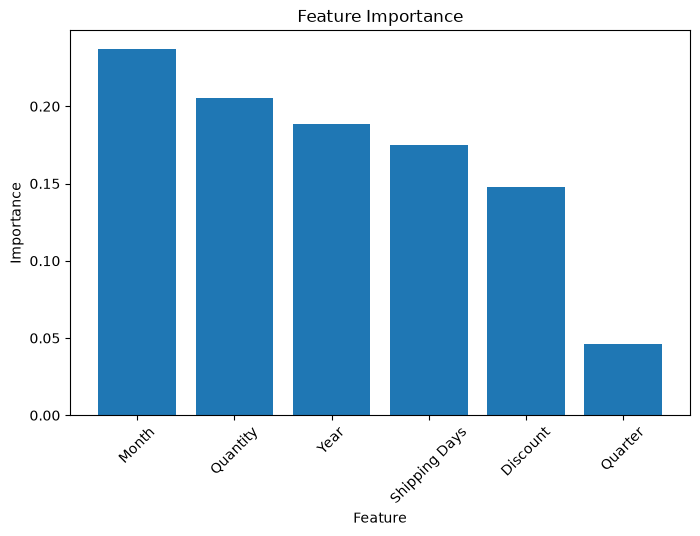

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Feature")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

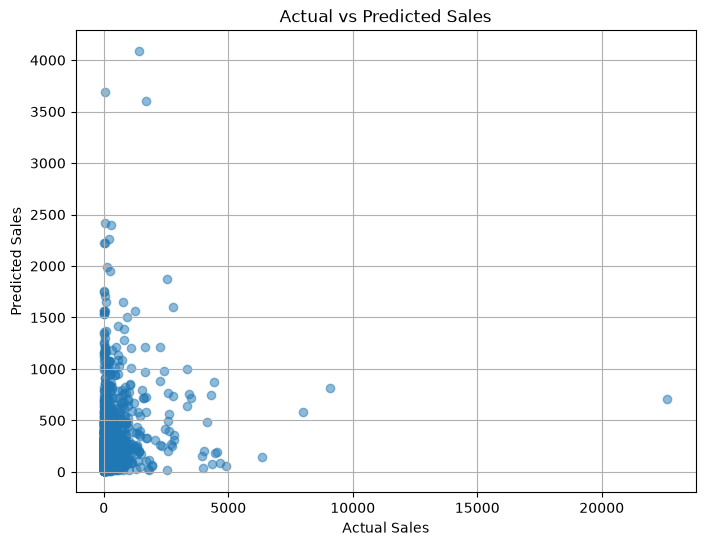

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.5
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.grid(True)

plt.show()

In [14]:
predictions = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": rf_predictions
})

predictions.head(20)

,Actual Sales,Predicted Sales
0,563.808,112.483006
1,36.672,66.608222
2,37.300,34.655005
3,212.058,471.787455
4,171.288,51.240754
5,99.136,1166.939187
6,340.182,439.793544
7,17.380,68.694715
8,22.620,13.164124
9,71.632,428.754262


# Business Interpretation

## Key Findings

- Random Forest performed better than Linear Regression.
- Quantity and Discount were among the most influential features.
- The model can support demand forecasting and inventory planning.
- The predicted sales closely followed actual sales for many observations, indicating that the model captures meaningful patterns in the data.